# Going further - the same steps on a classification problem

`1a_EDA_data_processing` worked through one dataset, Ames Housing, where the
target is a price - a *regression* problem. This notebook applies the same
sequence of steps to the Iris dataset, where the target is a species - a
*classification* problem.

The processing steps are almost the same. Two things are not, and both are
marked below:

- the train/test split has to preserve the class balance, which is what `stratify` does,
- the target is a label, not a quantity, so scaling it makes no sense.

The Iris dataset is used again on day 2.

## Part 0 - Setup

Run this cell first, in every notebook. It fetches the course repository into
the Colab session and moves into the `notebooks/` folder, so that the
`../data/...` paths work.

It is safe to run more than once, and safe after a restart.

Note: outside Colab the cell does nothing except report the working directory.
Start Jupyter from inside `notebooks/` and the paths work the same way.

If it prints `data ok: True`, you are set.

In [1]:
# --- SETUP: run this first ---  [lares-setup-v1]
# works in Colab and locally, safe to run more than once
import os, sys, subprocess
REPO = "ai_bootcamp_foundations"
if "google.colab" in sys.modules:
    if not os.path.isdir(f"/content/{REPO}"):
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/unizg-fer-lares/{REPO}.git"],
                       cwd="/content", check=True)
    os.chdir(f"/content/{REPO}/notebooks")
print("cwd:", os.getcwd(), "| data ok:", os.path.isdir("../data"))

cwd: C:\Users\novak\Desktop\files\notebooks | data ok: True


In [2]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# same plot styling as in 1a
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt
tex_fonts = {
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 20,
    "font.size": 20,
    "figure.titlesize": 20,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
}

plt.rcParams.update(tex_fonts)

## Part 1 - The dataset

The [Iris flower data set](https://archive.ics.uci.edu/ml/datasets/iris) is a multivariate data set introduced by the British statistician and biologist Ronald Fisher in his 1936 paper. The use of multiple measurements in taxonomic problems as an example of linear discriminant analysis. Two of the three species were collected in the Gaspé Peninsula "all from the same pasture, and picked on the same day and measured at the same time by the same person with the same apparatus".

The data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters. Based on the combination of these four features, the **goal is to develop a model that is able to distinguish the species from each other**.

![title](../data/img/iris.png)

### Load dataset

In [3]:
# load the dataset and print the first couple of rows
iris = pd.read_csv("../data/iris/Iris.csv", index_col='Id')
iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# basic dataset properties
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


## Part 2 - Check basic dataset properties


In [5]:
# basic dataset statistics
iris.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# basic statistcs per iris species
iris.groupby('Species').describe().transpose()

Species              Iris-setosa  Iris-versicolor  Iris-virginica
SepalLengthCm count    50.000000        50.000000       50.000000
              mean      5.006000         5.936000        6.588000
              std       0.352490         0.516171        0.635880
              min       4.300000         4.900000        4.900000
              25%       4.800000         5.600000        6.225000
              50%       5.000000         5.900000        6.500000
              75%       5.200000         6.300000        6.900000
              max       5.800000         7.000000        7.900000
SepalWidthCm  count    50.000000        50.000000       50.000000
              mean      3.418000         2.770000        2.974000
              std       0.381024         0.313798        0.322497
              min       2.300000         2.000000        2.200000
              25%       3.125000         2.525000        2.800000
              50%       3.400000         2.800000        3.000000
              75%       3.675000         3.000000        3.175000
              max       4.400000         3.400000        3.800000
PetalLengthCm count    50.000000        50.000000       50.000000
              mean      1.464000         4.260000        5.552000
              std       0.173511         0.469911        0.551895
              min       1.000000         3.000000        4.500000
              25%       1.400000         4.000000        5.100000
              50%       1.500000         4.350000        5.550000
              75%       1.575000         4.600000        5.875000
              max       1.900000         5.100000        6.900000
PetalWidthCm  count    50.000000        50.000000       50.000000
              mean      0.244000         1.326000        2.026000
              std       0.107210         0.197753        0.274650
              min       0.100000         1.000000        1.400000
              25%       0.200000         1.200000        1.800000
              50%       0.200000         1.300000        2.000000
              75%       0.300000         1.500000        2.300000
              max       0.600000         1.800000        2.500000

In [7]:
# print just the means per species for easier visualisation
iris.groupby('Species').aggregate('mean')

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [8]:
# count species (yeah, we know its three - just showing off)
iris["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [9]:
# count the available data per each species
iris['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## Part 3 - Exploratory data analysis (EDA)


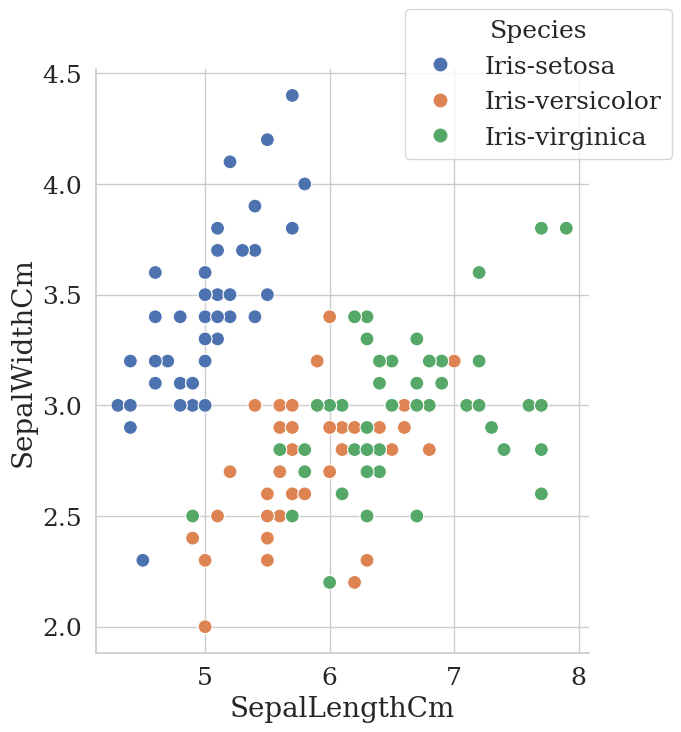

In [10]:
# scatter plot for sepal width/length per species - see if we can easily separate them through sepal differences
g = sns.relplot(data=iris, x='SepalLengthCm', y='SepalWidthCm', hue="Species", kind='scatter', s=100)
g.fig.set_size_inches((12,8))
sns.move_legend(g,'lower center',ncol=1, bbox_to_anchor=(.6,0.8), frameon=True);

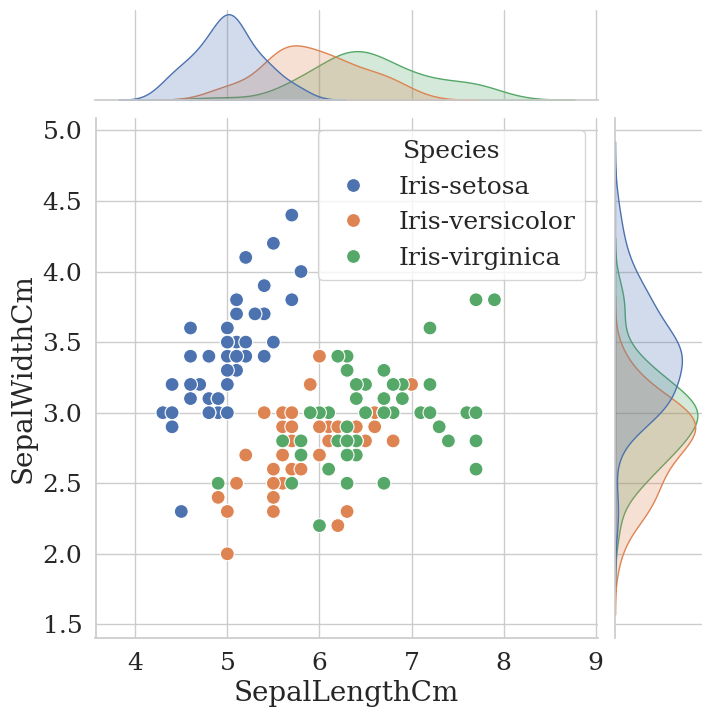

In [11]:
# add distributions of sepal length and width to help with visualization
g = sns.jointplot(x="SepalLengthCm", y="SepalWidthCm", data=iris, s=100, hue='Species')
g.fig.set_size_inches((8,8));

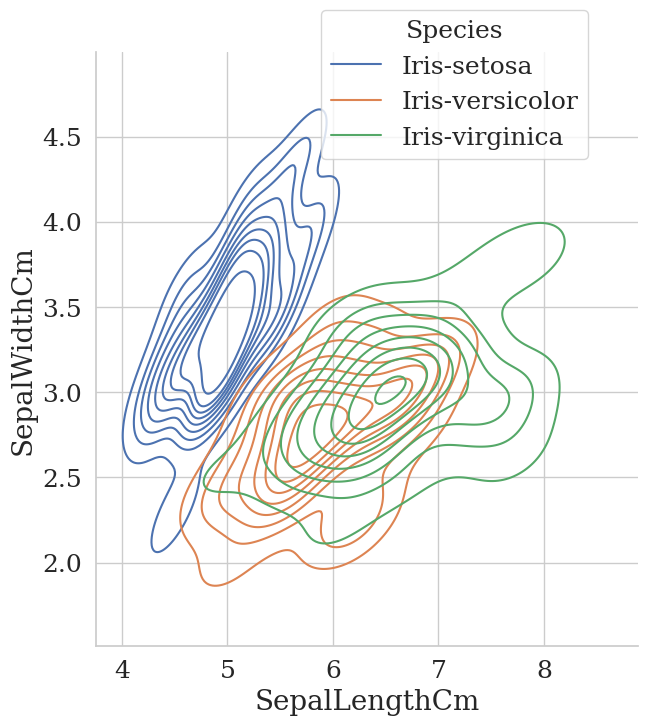

In [12]:
# kde for sepals per species
g = sns.displot(data=iris, x="SepalLengthCm", y="SepalWidthCm", kind='kde', hue='Species')
g.fig.set_size_inches((12,8))
sns.move_legend(g,'center',ncol=1, bbox_to_anchor=(0.45,0.9), frameon=True)

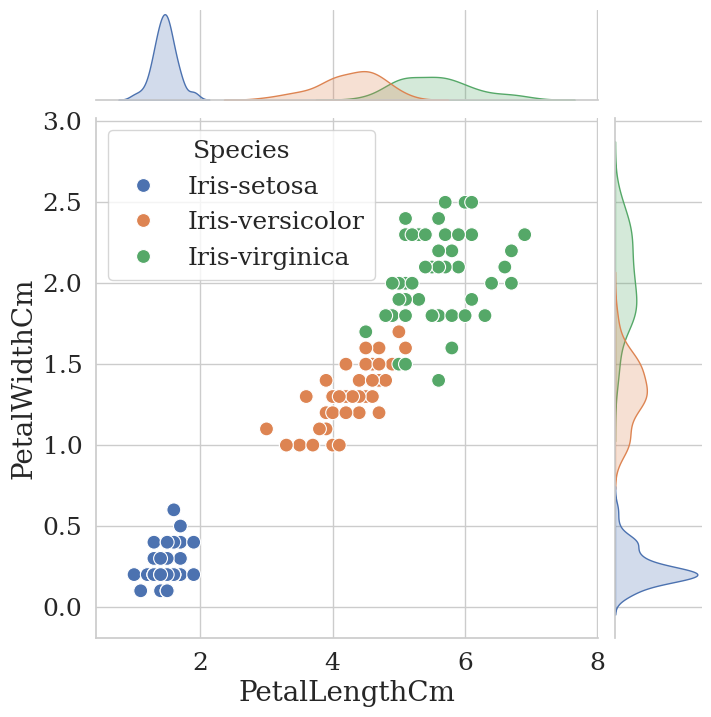

In [13]:
# scatter with distributions but for petals data this time
g = sns.jointplot(x="PetalLengthCm", y="PetalWidthCm", data=iris, s=100, hue='Species')
g.fig.set_size_inches((8,8));

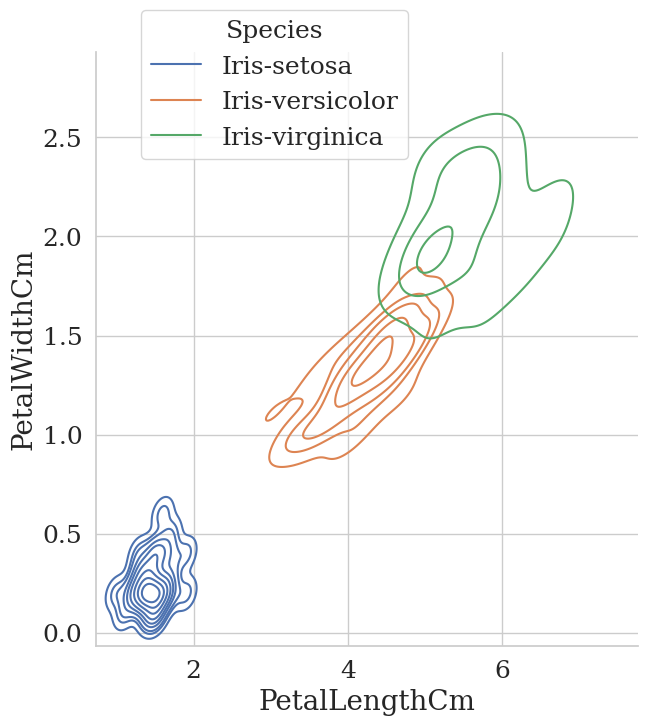

In [14]:
# kde for petals per species
g = sns.displot(data=iris, x="PetalLengthCm", y="PetalWidthCm", kind='kde', hue='Species')
g.fig.set_size_inches((12,8))
sns.move_legend(g,'center',ncol=1, bbox_to_anchor=(0.30,0.9), frameon=True)

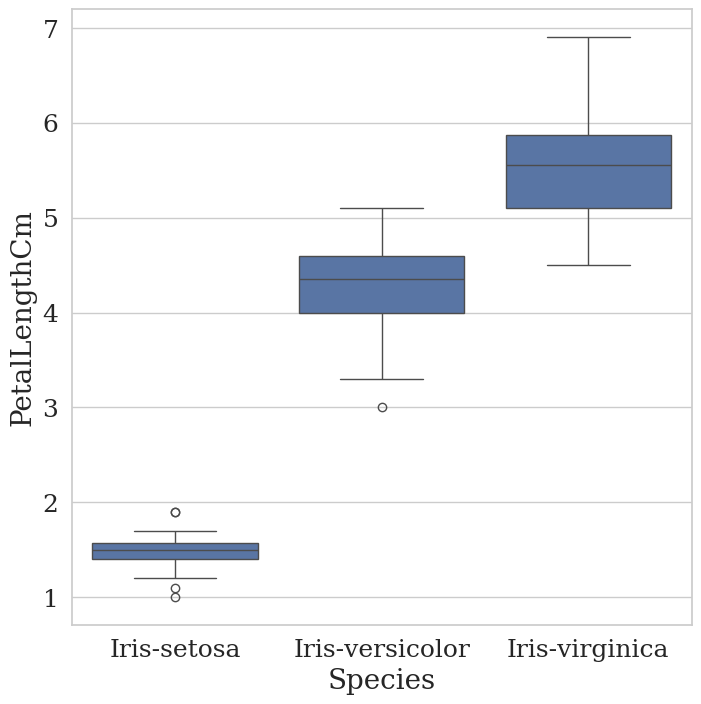

In [15]:
# look at an individual feature (petal length) through a box plot
plt.figure(figsize=(8,8))
sns.boxplot(x="Species", y="PetalLengthCm", data=iris);

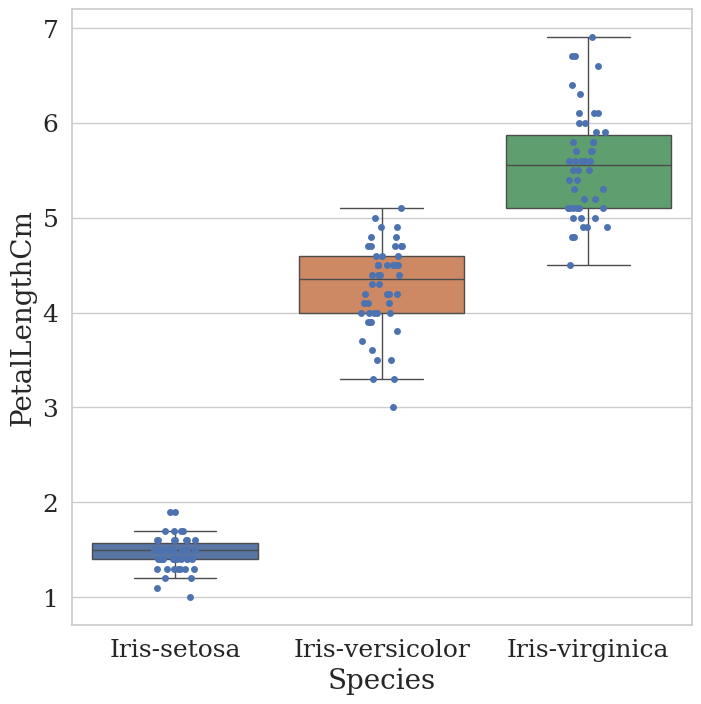

In [16]:
# add individual points on top of the boxplot
plt.figure(figsize=(8,8))
ax = sns.stripplot(x="Species", y="PetalLengthCm", data=iris, jitter=True, edgecolor="auto")
ax = sns.boxplot(x="Species", y="PetalLengthCm", data=iris, hue="Species", showfliers=False)

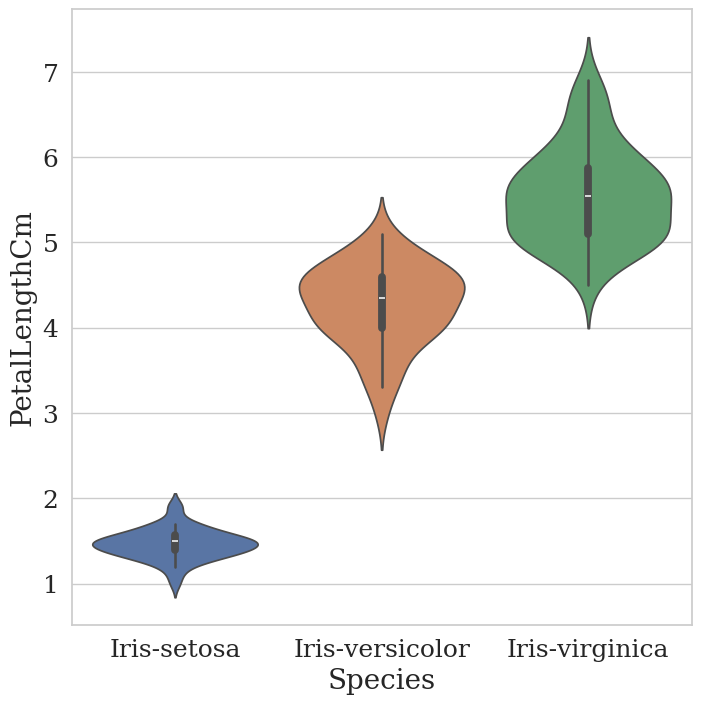

In [17]:
# violin plot combines benefits of the previous two plots
# "fatter" parts represent denser regions, and "thiner" sparser regions of the data
plt.figure(figsize=(8,8))
sns.violinplot(x="Species", y="PetalLengthCm", data=iris, hue="Species");

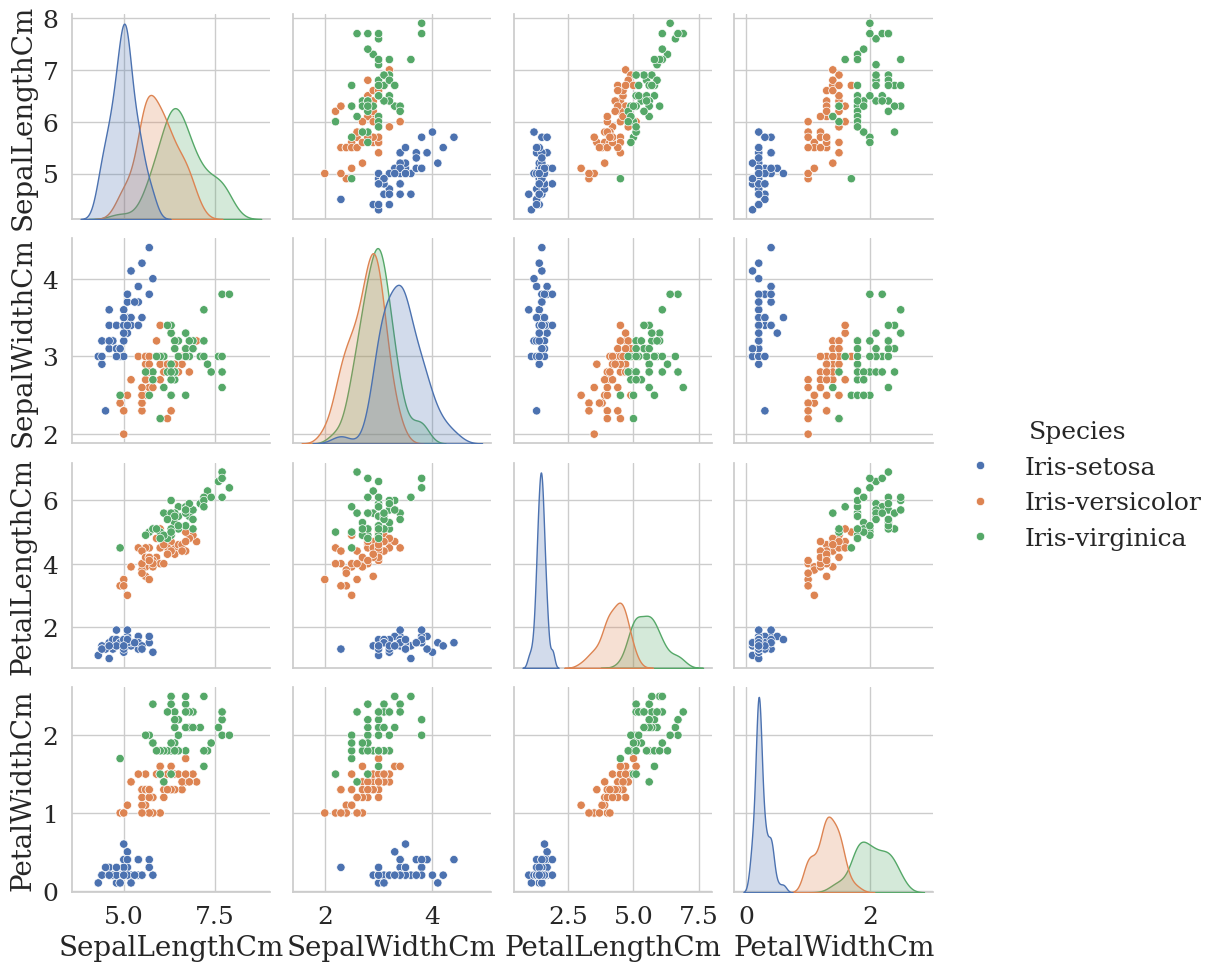

In [18]:
# check bivariate relations between each pair of features
g = sns.pairplot(iris, hue="Species", height=2.5);

In [19]:
# calculate corellations between the available features
iris.corr(numeric_only=True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


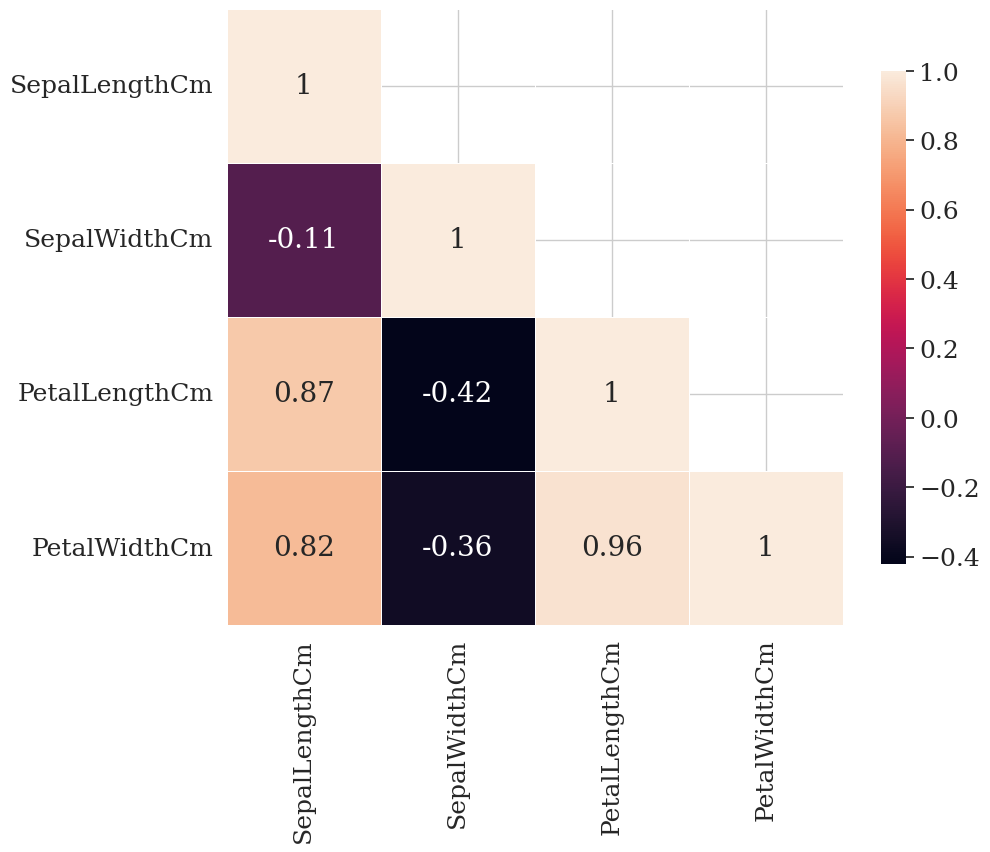

In [20]:
# plot correlations between features
corr = iris.corr(numeric_only=True)

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Want diagonal elements as well
mask[np.diag_indices_from(mask)] = False

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            mask=mask, square=True, annot=True, linewidths=.5, cbar_kws={"shrink": .8});

## Part 4 - Process the training dataset


In [21]:
# change species names to numbers (labels) in a manual way
iris = iris.replace({"Iris-setosa": 0, "Iris-versicolor": 1, "Iris-virginica": 2})
iris

C:\Users\novak\AppData\Local\Temp\ipykernel_19248\386039639.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iris = iris.replace({"Iris-setosa": 0, "Iris-versicolor": 1, "Iris-virginica": 2})


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,0
2,4.9,3.0,1.4,0.2,0
3,4.7,3.2,1.3,0.2,0
4,4.6,3.1,1.5,0.2,0
5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,2
147,6.3,2.5,5.0,1.9,2
148,6.5,3.0,5.2,2.0,2


In [22]:
# split into inputs and outpus
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = iris[["Species"]]

In [23]:
# split into train-test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state = 1)

In [24]:
# check the distribution of species in the training dataset
np.unique(y_train, return_counts=True)

(array([0, 1, 2], dtype=int64), array([39, 37, 44], dtype=int64))

In [25]:
# check the distribution of species in the test dataset
np.unique(y_test, return_counts=True)

(array([0, 1, 2], dtype=int64), array([11, 13,  6], dtype=int64))

The split above is random. With three classes of 50 samples each, a random
split does not guarantee that all three are represented in the same proportion
on both sides - check the counts printed above and below.

`stratify=y` forces the split to keep the class proportions. Re-run the split
with it and compare the counts.

Note: this matters more the rarer a class is. With three balanced classes the
damage is small, with a class that has twenty samples in ten thousand it is not.

In [26]:
# the same split, keeping the class proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state = 1, stratify=y)

In [27]:
# check the distribution of species in the training dataset
np.unique(y_train, return_counts=True)

(array([0, 1, 2], dtype=int64), array([40, 40, 40], dtype=int64))

In [28]:
# check the distribution of species in the test dataset
np.unique(y_test, return_counts=True)

(array([0, 1, 2], dtype=int64), array([10, 10, 10], dtype=int64))

## Part 5 - Save the dataset


In [29]:
# save the training and test parts of the dataset for later usage
X_train.to_csv("../data/iris/X_train.csv"); y_train.to_csv("../data/iris/y_train.csv");
X_test.to_csv("../data/iris/X_test.csv"); y_test.to_csv("../data/iris/y_test.csv");

### Conclusions - overall:
- *the processing sequence is the same for regression and classification - load, inspect, explore, encode, split, scale,*
- *what changes is the target: a quantity in one case, a label in the other,*
- *a random split can distort the class balance, and `stratify` is the fix,*
- *the target of a classification problem is not scaled - the classes are names, not amounts,*
- *the petal features separate the species far better than the sepal features, which is visible in the pairplot long before any model is fitted.*


_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - Foundations of AI_  
_Notebook: 1y_Going_further_classification_  

_References:_
- _Iris flower data set: https://archive.ics.uci.edu/ml/datasets/iris_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_
